###### To solve a puzzle, you are given an initial state and a goal state.
###### Target is to reach goal state from initial state using puzzle rules.
######  We can move blank tile only on left, right, up, and down
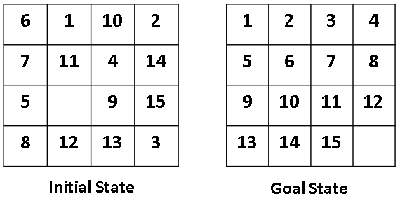

# Generate an intial state of NPuzzle

In [11]:
import matplotlib.pyplot as plt
import random
import math
import numpy as np

def drawPuzzle(state):
    #Reshape the 1D state into a 2D grid
    n = int(math.sqrt(len(state)))
    grid = np.array(state).reshape(n, n)

    #Create the plot
    fig, ax = plt.subplots()

    #Display the grid
    ax.matshow(grid, cmap =plt.cm.Blues)

    #Add text annotations to each cell
    for i in range(n):
        for j in range(n):
            if grid[i, j] == 0:
                  ax.text(j, i, ' ', va='center', ha='center') #Display blank space as empty
            else:
                  ax.text(j, i, str(grid[i, j]), va='center', ha='center')

    #Remove ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])

    plt.show()

[7, 5, 2, 4, 6, 3, 8, 1, 0]


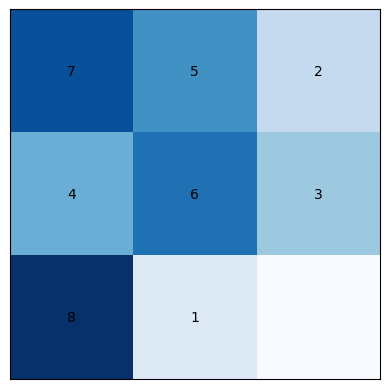

In [12]:
def generateState(n):
    if n is None:
      n = random.choice([3,4])
    state = list(range(n**2))
    random.shuffle(state)
    return state
initialState = generateState(None)
print(initialState)
drawPuzzle(initialState)

**Get Dimension**

In [13]:
def dimension(state):
  return int(math.sqrt(len(state)))

dimension(initialState)

3

# Calculate inversion

Inversion is a pair of tiles that are in the reverse order from where they ought to be. In our case, the bigger number is in front of the smaller one.



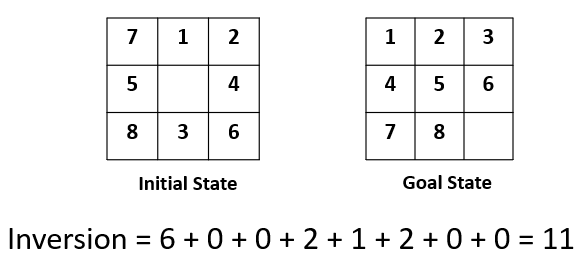

In [14]:
def inversionCount(state):
    count = 0
    for i, a in enumerate(state):
      if a > 0:
        for b in state[i+1:]:
          if b > 0 and a > b:
            count += 1
    return count

inversionCount(initialState)

17

In [15]:
initialState.index(0)

8

# **Find blank row**

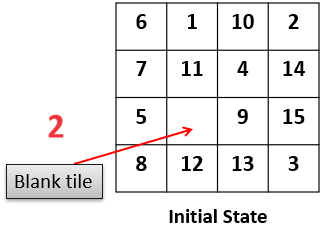

In [16]:
# find row position of the blank tile
def get_blank_row(state):
  dim = dimension(state)
  blank_index = state.index(0)
  row_from_top = math.ceil((blank_index + 1) / dim)
  row_from_bottom = dim - row_from_top + 1
  return row_from_bottom
  get_blank_row(initialState)

# Solvability Rules

In [17]:
# apply the rules to decide solvability
#  N, I, R
# define a method to return solvability (input S)
# return True if solvable or False if not


def isSolvable(state):
  # Use the already defined 'dimension' function instead of 'get_dim'
  N = dimension(state)
  I = inversionCount(state)
  R = get_blank_row(state)
  print(N,I,R)
  # decide solvability
  # check rules
  # Solvability rule for odd dimensions:
  if N % 2 == 1:
    return I % 2 == 0

  # Solvability rule for even dimensions:
  else:
    if R % 2 == 1:
      return I % 2 == 0
    else:
      return I % 2 == 1
  return False

In [28]:
isSolvable(initialState)

3 17 1


False

Continue to generate untill a solvable state is generated.

3 16 1
A solvable state was found at step 1


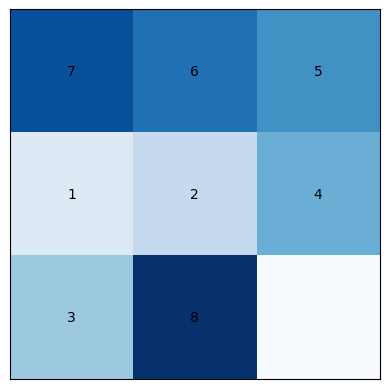

In [25]:
steps = 0
while(True):
  steps += 1
  s = generateState(3)
  if isSolvable(s):
    print(f'A solvable state was found at step {steps}')
    drawPuzzle(s)
    break
  if steps >= 100:
    print(f'Solvable state was not found in the first {steps} steps')
    break